In [52]:
import numpy as np 
import matplotlib.pyplot as plt

def plot_fit_dms(x, y1, y2, degree, xlabel, legend):
    p1 = np.polyfit(x, y1, deg=degree)
    p2 = np.polyfit(x, y2, deg=degree)
    x_plot = np.linspace(min(x), max(x), 100)

    plt.figure(figsize=(12, 8))
    plt.plot(x_plot, 
             np.polyval(p1, x_plot), 
             color='blue', 
             linewidth = 2.5,
             label=f'$μ_x$') #p_x
    
    plt.plot([min(x), max(x)], 
             [0,0], 
             ':', 
             color='red',
             linewidth = 2.5,
             label=f'$μ_y$') #p_y
    
    plt.plot(x_plot, 
             np.polyval(p2, x_plot), 
             '-.',
             color='purple',
             linewidth = 2.5,
             label=f'$μ_z$') #p_z

    plt.xlim(min(x), max(x))
    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel(f'$μ$ (Debyes)', fontsize=16)
    plt.tick_params(axis='both', labelsize=16)

    if legend:
        plt.legend(fontsize=16)
    

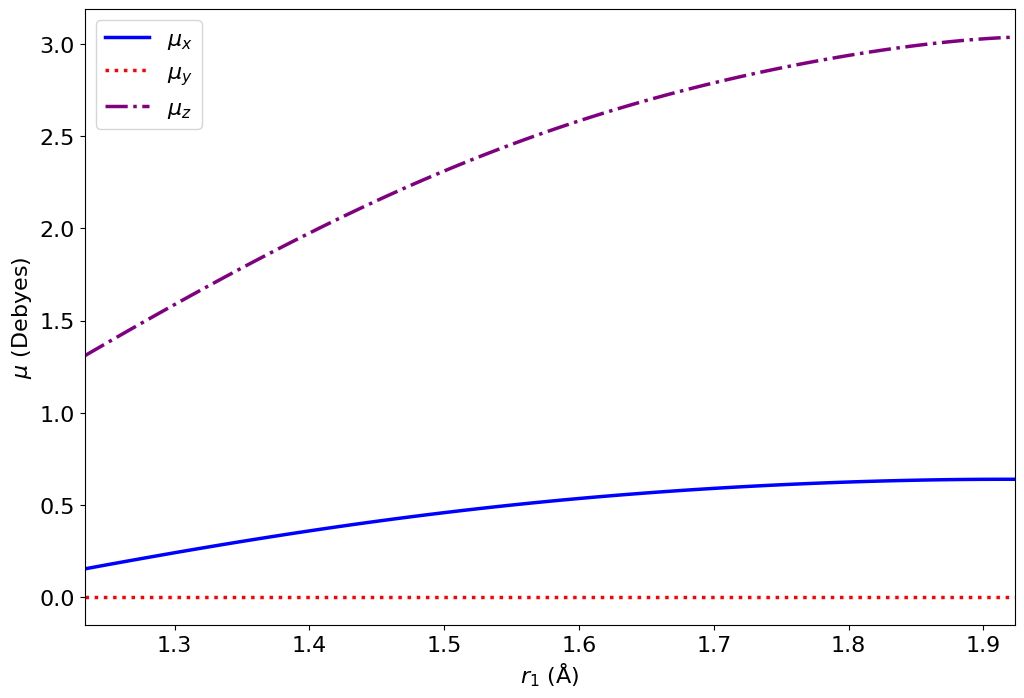

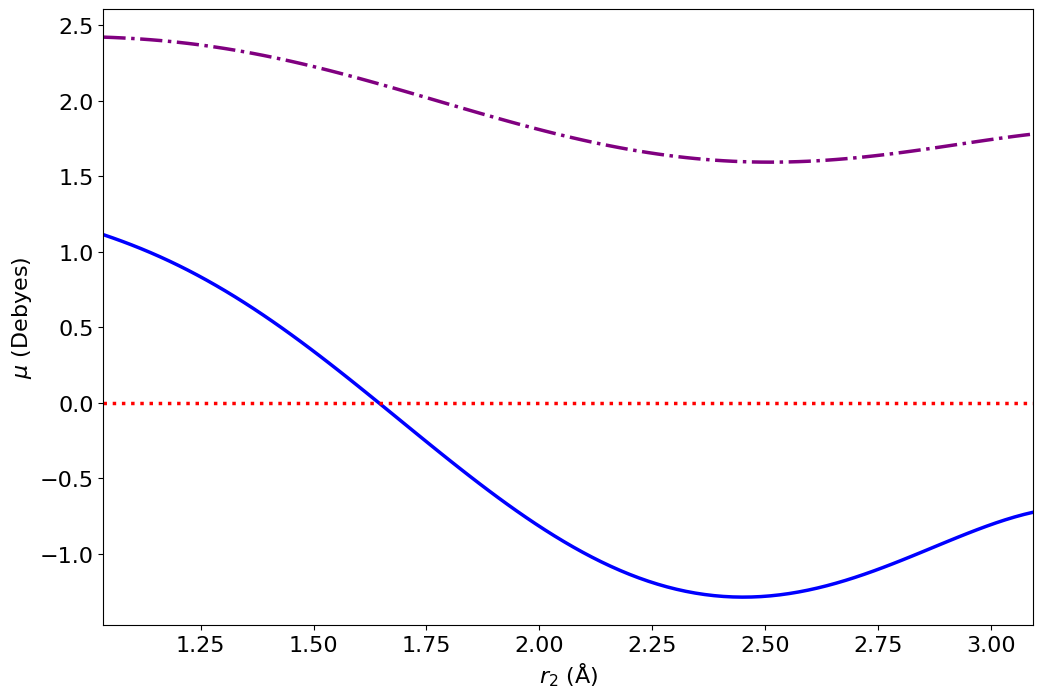

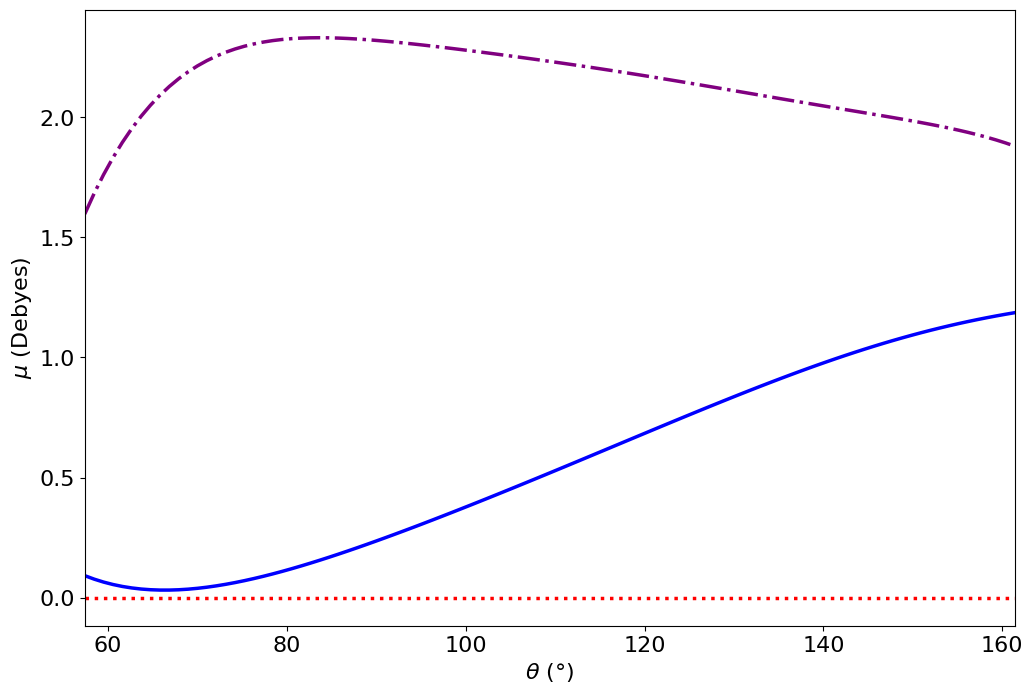

In [54]:
dms_files = ['r1_dms.txt', 'r2_dms.txt', 'theta_dms.txt']
save_files = ['r1_dms.png', 'r2_dms.png', 'theta_dms.png']
for i in range(3):
    dms_data = np.loadtxt(dms_files[i])
    p_x = dms_data[:, -3]
    p_z = dms_data[:, -2]
    coordinate = dms_data[:, i]

    #get coordinate in ascending order for plotting
    sort_idx = np.argsort(coordinate)
    coordinate = coordinate[sort_idx]
    p_x = p_x[sort_idx]
    p_z = p_z[sort_idx]

    x_coord = [r'$r_1$ (Å)', r'$r_2$ (Å)', r'$\theta$ (°)']
    plot_fit_dms(coordinate, p_x, p_z, 6, x_coord[i], True if i == 0 else False)
    plt.savefig(save_files[i], dpi=300, bbox_inches='tight')